In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('/content/world_happiness_2023.csv')
df.columns = ['Country','Region','Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']
print(f"{len(df)} countries loaded")
print(df.head())

63 countries loaded
       Country                        Region  Score     GDP  Social_Support  \
0      Finland                Western Europe  7.804  10.775           0.954   
1      Denmark                Western Europe  7.586  10.933           0.954   
2      Iceland                Western Europe  7.525  10.878           0.983   
3       Israel  Middle East and North Africa  7.473  10.527           0.916   
4  Netherlands                Western Europe  7.464  11.015           0.939   

   Life_Expectancy  Freedom  Generosity  Corruption  
0             71.9    0.949       0.142       0.179  
1             72.7    0.931       0.168       0.234  
2             72.5    0.961       0.260       0.150  
3             72.4    0.903       0.149       0.826  
4             72.4    0.879       0.240       0.296  


Step 1 — The Seaborn default

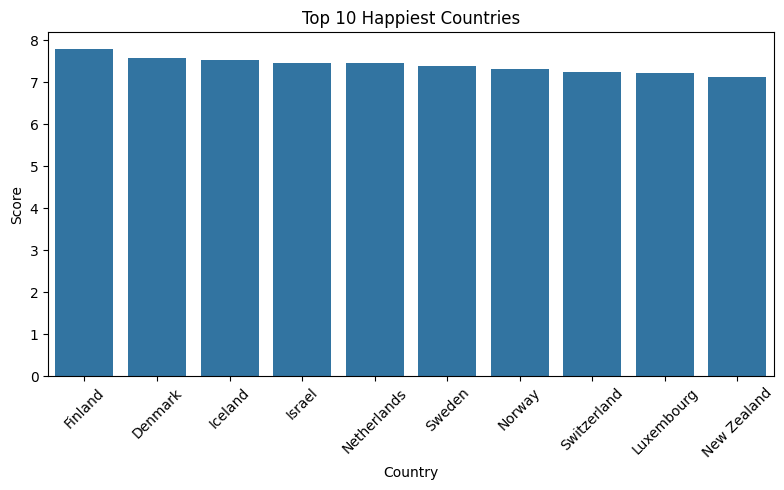

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = df.nlargest(10, 'Score')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, x='Country', y='Score', ax=ax)
ax.set_title('Top 10 Happiest Countries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step 2 — Plotly Express w/ some Customizations

In [3]:
fig = px.bar(
    top10.sort_values('Score'),       # Rule 2: sort
    x='Score', y='Country',
    orientation='h',                  # Rule 3: horizontal
    title='Top 10 Happiest Countries 2023',
    height=500

)
fig.show()

Step 3 — Apply all 4 rules

In [4]:
fig = px.bar(
    df.nlargest(15, 'Score').sort_values('Score'),
    x='Score', y='Country',
    orientation='h',
    title='Nordic countries occupy 5 of the top 7 happiest nations in 2023',
    labels={'Score': 'Happiness Score (0–10)', 'Country': ''},
    color_discrete_sequence=['#2E75B6']
)
fig.update_layout(
    xaxis=dict(range=[0, 8.5]),      # Rule 1: make sure to have zero baseline — always
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis_gridcolor='#EEEEEE',
    yaxis_gridcolor='white',
    showlegend=False,
    margin=dict(l=10, r=30, t=50, b=40),
    height=550
)

fig.update_traces(marker_line_width=0)
fig.show()

Step 4 — Colour as emphasis

In [5]:
# Grey everything, highlight one group — viewer's eye goes straight to colour

top15 = df.nlargest(15, 'Score').sort_values('Score')

# Add a highlight column so px can map colours declaratively
top15 = top15.copy()
top15['highlight'] = top15['Region'].apply(
    lambda r: 'Western Europe' if r == 'Western Europe' else 'Other'
)

# --- px as the starting point ---
fig = px.bar(
    top15,
    x='Score', y='Country',
    orientation='h',
    color='highlight',
    color_discrete_map={
        'Western Europe': '#2E75B6',  # blue — stands out
        'Other':          '#D0D0D0'   # grey — recede into background
    },
    title='Western European nations dominate global happiness rankings',
    labels={'Score': 'Score (0-10)', 'Country': '', 'highlight': ''},
    height=550
)

# --- customise via update_*
fig.update_traces(marker_line_width=0)

fig.update_layout(
    xaxis=dict(range=[0, 8.5], gridcolor='#EEEEEE'),
    yaxis=dict(gridcolor='white'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    margin=dict(l=10, r=30, t=50, b=40),
    showlegend=False
)

# adding a text box annotation for clarification of color usage
fig.add_annotation(
    x=7.9, y='United States',
    text='Western Europe in blue',
    showarrow=False,
    font=dict(color='#2E75B6', size=11),
    bgcolor='white', bordercolor='#2E75B6', borderwidth=1, borderpad=4
)

fig.show()


Step 5 — Stacked bar: composition story

In [6]:
sub = df[df['Region'].isin(['Western Europe','Sub-Saharan Africa',
                             'East Asia','Latin America and Caribbean','South Asia'])]
region_stack = (sub.groupby('Region')[['GDP','Social_Support','Life_Expectancy','Freedom']]
                .mean().reset_index())
region_stack['total'] = region_stack[['GDP','Social_Support','Life_Expectancy','Freedom']].sum(axis=1)
region_stack = region_stack.sort_values('total')

fig = px.bar(
    region_stack.melt(id_vars='Region',
                      value_vars=['GDP','Social_Support','Life_Expectancy','Freedom']),
    y='Region', x='value', color='variable',
    orientation='h', barmode='stack',
    title='Western Europe leads on all four sub-factors — Sub-Saharan Africa trails on every one',
    labels={'value': 'Contribution Score', 'variable': 'Factor', 'Region': ''},
    color_discrete_sequence=['#2E75B6','#70AD47','#FFC000','#E63946']
)
fig.update_layout(
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(gridcolor='#EEEEEE'),
    legend=dict(orientation='h', y=1.08),
    margin=dict(l=10, r=30, t=65, b=40)
)
fig.update_traces(marker_line_width=0)
fig.show()

# Which sub-factor is easiest to compare across regions? Hardest?
# GDP (bottom, zero baseline) = easy. Freedom (top, floating) = hard